# Comprehensive Notes on Multicollinearity

## Table of Contents
1. [What is Multicollinearity?](#what-is-multicollinearity)
2. [When is Multicollinearity Problematic?](#when-is-multicollinearity-problematic)
3. [Mathematical Understanding](#mathematical-understanding)
4. [Types of Multicollinearity](#types-of-multicollinearity)
5. [Detection Methods](#detection-methods)
6. [Solutions to Multicollinearity](#solutions-to-multicollinearity)
7. [Practical Code Examples](#practical-code-examples)

---

## 1. What is Multicollinearity?

**Multicollinearity** is a statistical phenomenon that occurs when two or more independent variables in a multiple regression model are **highly correlated**. This means these variables exhibit a strong linear relationship, making it difficult to isolate the individual effects of each variable on the dependent variable.

**Simple Analogy:** Imagine you're trying to predict a person's weight (dependent variable) using their height (independent variable 1) and their shoe size (independent variable 2). Since taller people generally have larger shoe sizes, these two independent variables are highly correlated. This is multicollinearity. It becomes difficult to isolate the unique effect of height or shoe size on weight because they carry overlapping information.


```mermaid
graph TD
    A[Independent Variables] --> B{Are they correlated?}
    B -->|Yes| C[Multicollinearity Present]
    B -->|No| D[No Multicollinearity]
    C --> E[Difficult to interpret coefficients]
    C --> F[Unstable estimates]
    C --> G[Inflated standard errors]
```

---

## 2. When is Multicollinearity Problematic?
**Crucial Distinction**: Multicollinearity is only a problem for **inference**. It does not affect the model's predictive power if the same correlated structure is maintained in new data.

**Inference vs Prediction:**

```mermaid
graph TD
    A[Modeling Goal] --> B{Inference or Prediction?};
    B -- Inference --> C[Understand Relationships];
    C --> D["Goal: Interpret coefficients,<br>test hypotheses"];
    D --> E["Multicollinearity is a <br><b>Major Problem</b>"];
    B -- Prediction --> F[Make Accurate Forecasts];
    F --> G["Goal: Minimize error on <br>new, unseen data"];
    G --> H["Multicollinearity is <br><b>Less of a Concern</b>"];
```

**Key takeaway:** If your main goal is to explain how predictors affect the outcome (inference), multicollinearity is a significant problem. If you only care about predicting future outcomes and the correlation structure remains the same, you can often ignore it.

### Problems Caused by Multicollinearity:
**Consequences for Inference:**
1. **Difficulty Identifying Important Predictors:** Since the information is shared, it's impossible to determine which variable is truly driving the effect.

2. **Inflated Standard Errors:** Multicollinearity leads to larger standard errors for regression coefficients, which decreases statistical power and makes it challenging to determine the true relationship.

    - **Implication:** You are more likely to fail to reject the null hypothesis (Type II error), meaning you might miss a truly significant relationship.

3. **Unstable and Unreliable Estimates:** The regression coefficients become highly sensitive to small changes in the data. Adding or removing a few data points can drastically change the coefficient values, making them unreliable and difficult to interpret.

   - Animation Concept: Imagine a seesaw that is perfectly balanced. A very small nudge (a new data point) can cause the seesaw to tip drastically. This is how coefficients behave under severe multicollinearity.

```mermaid
mindmap
  root((Multicollinearity Problems))
    Difficulty Identifying Important Predictors
      High correlation between variables
      Cannot determine individual impact
    Inflated Standard Errors
      Larger confidence intervals
      Decreased statistical power
      Harder to find significance
    Unstable Estimates
      Sensitive to small data changes
      Unreliable coefficient estimates
      Difficult interpretation
```

---

## 3. Mathematical Understanding

To truly understand multicollinearity, we need to understand how it affects the mathematical foundation of linear regression.

### The Mathematical Problem:

In multiple linear regression, we solve:
$$\beta = (X^TX)^{-1}X^Ty$$

When multicollinearity exists:
- $X^TX$ becomes **near-singular** (almost non-invertible)
- Small changes in data cause large changes in $\beta$
- The inverse $(X^TX)^{-1}$ has very large values

```mermaid
graph TD
    A[Design Matrix X] --> B[Compute XᵀX]
    B --> C{Check Eigenvalues}
    C -->|Very different magnitudes| D[Ill-conditioned Matrix]
    C -->|Similar magnitudes| E[Well-conditioned Matrix]
    D --> F[High Condition Number]
    D --> G[Multicollinearity Present]
    E --> H[Low Condition Number]
    E --> I[No Multicollinearity]
```

### Perfect Multicollinearity:

Perfect multicollinearity occurs when one predictor/independent variable is an **exact linear combination** of one or more other predictors. This means the columns of the design matrix X are linearly dependent.

$$X_3 = 2X_1 + 3X_2$$

This makes $X^TX$ **singular** (non-invertible), and the regression cannot be computed.
**The Consequence: A Singular Matrix**
When there is perfect multicollinearity, the $X^TX$ matrix becomes **singular**. This means its determinant is zero, and it is **not invertible**.

**Mathematical Implication**: If $X^TX$ is singular, the Normal Equation has no unique solution. 

$$
\boldsymbol{\beta} = (X^{T}X)^{-1}X^{T}y
$$

The model has an infinite number of possible coefficient sets that would fit the data equally well.

### Non-Perfect Multicollinearity
This is the more common scenario in real-world data. It occurs when independent variables are highly correlated but not perfectly linearly dependent.

**Mathematical Implication:** The ($X^TX$) matrix is **not singular** and can be inverted. However, its inverse will be numerically unstable. The diagonal elements of $(X^{T}X)^{-1}$, which are used to calculate the standard errors of the coefficients, will be excessively large.

**Result**: The standard errors are inflated, leading to large p-values and a conclusion that the variables are not statistically significant, even if they are important.


## 4. Types of Multicollinearity

```mermaid
graph TD
    A[Multicollinearity Types] --> B[Structural]
    A --> C[Data-Driven]
    
    B --> D[Created by model construction]
    B --> E[Interaction terms]
    B --> F[Polynomial terms]
    B --> G[Without proper scaling]
    
    C --> H[Due to data patterns]
    C --> I[Not by design]
    C --> J[Observed correlations]
```

### 1. Structural Multicollinearity
- Arises from how variables are defined or model is constructed
- Occurs when one variable is created as a linear combination of others
- Common with interaction terms or polynomial terms without proper scaling
> **Example:** Including X1, X2, and X3 where X3 = X1 + X2. This creates a perfect linear relationship, making it impossible to estimate the unique contribution of each variable.

### 2. Data-Driven Multicollinearity
- Occurs due to the specific dataset being analyzed
- High correlation exists due to observed data patterns
- Not a result of model construction
> **Example:** In a real estate dataset, variables like "Number of Rooms" and "House Size (sq ft)" are naturally correlated, as larger houses tend to have more rooms.
---

## 5. Detection Methods

### Method 1: Correlation Matrix

This is the most straightforward first check.

- **Method**: Examine the pairwise correlation matrix of your predictor variables.

- **Rule of Thumb**: A correlation coefficient with an absolute value greater than **0.8 or 0.9** is a strong indicator of multicollinearity.

**Animation Concept**: The correlation matrix is like a heatmap. Off-diagonal cells that are bright red or bright blue (indicating high correlation) are the red flags you're looking for.


```mermaid
graph LR
    A[Calculate Correlation Matrix] --> B[Examine Off-diagonal Elements]
    B --> C{"r" > 0.8 or 0.9?}
    C -->|Yes| D[High Multicollinearity]
    C -->|No| E[Low Multicollinearity]
```

**Code Example:**


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


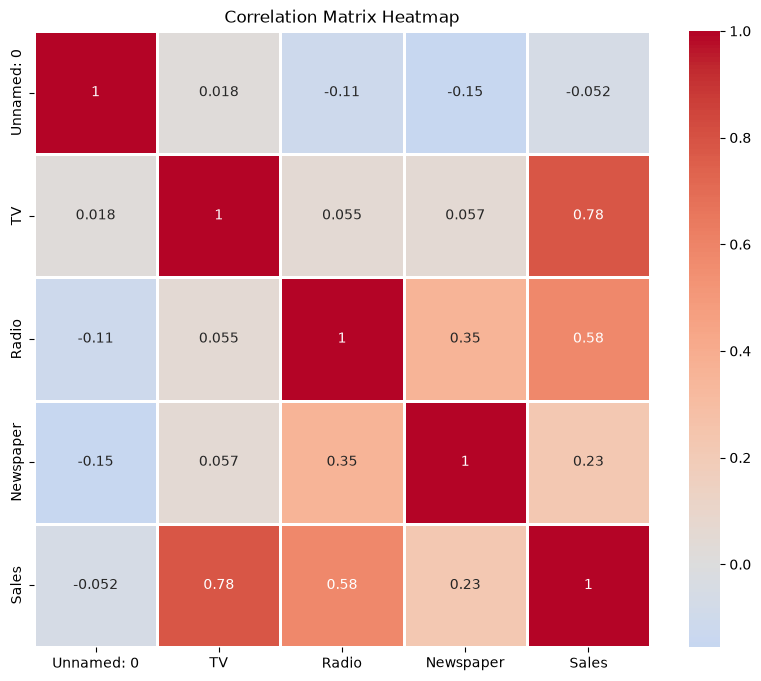

In [4]:
# Calculate correlation matrix
# The correlation matrix shows pairwise correlations between variables
# Diagonal elements are always 1 (correlation with itself)
# Off-diagonal elements show correlation between different variables
corr_matrix = df.corr()

# Visualize the correlation matrix using a heatmap
# High absolute values (>0.8 or >0.9) indicate potential multicollinearity
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [5]:
# Print correlation values for detailed inspection
print("Correlation Matrix:")
print(corr_matrix)


Correlation Matrix:
            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000


### Method 2: Variance Inflation Factor (VIF)

The Variance Inflation Factor (VIF) is the most widely used metric for detecting and quantifying multicollinearity.
**The Intuition Behind VIF**
VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity.

- VIF = 1: No correlation.
- 1 < VIF < 5: Moderate correlation.
- VIF > 5: High correlation (a cause for concern).
- VIF > 10: Severe multicollinearity (requires immediate action).

**Mathematical Formula:**
To calculate the VIF for a specific predictor variable $X_i$, you follow these steps:
1. **Regress $X_i$ against all other predictor variables** in the model (i.e., $X_i$ is the dependent variable).

2. **Calculate the R-squared** ($R_i{^2}$) from this auxiliary regression. $R_i{^2}$ represents the proportion of variance in $X_i$ explained by the other predictors.

3. **Compute the VIF** for $X_i$ using the formula:

$$VIF_i = \frac{1}{1 - R_i^2}$$

If the other predictors explain a large portion of the variance in $X_i$ (meaning $R_i{^2}$ is high), the denominator becomes very small, and the VIF becomes very large, indicating a problem.

```mermaid
graph TD
    A[Start] --> B[Fit a Linear Regression Model];
    B --> C[For each Predictor Variable Xi];
    C --> D[Regress Xi on All Other Predictors];
    D --> E[Calculate R² from this Regression];
    E --> F["Compute VIF = 1 / (1 - R²)"];
    F --> G{VIF > 5 or 10?};
    G -- No --> H[Variable is Fine];
    G -- Yes --> I[Multicollinearity Detected!];
    I --> J[Take Corrective Action];
    H --> K[Proceed to Next Variable];
```


**Code Example:**


In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, features):
    """
    Calculate Variance Inflation Factor for each feature
    
    Parameters:
    -----------
    data : pandas DataFrame
        The dataset containing all features
    features : list
        List of feature column names to calculate VIF for
    
    Returns:
    --------
    pandas DataFrame
        DataFrame with features and their VIF values
    """
    # Create a DataFrame to store VIF values
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    
    # Calculate VIF for each feature
    vif_values = []
    for feature in features:
        # Extract all features except the current one
        # VIF measures how much the variance of a coefficient is inflated
        # due to multicollinearity with other predictors
        X = data[features]
        
        # Calculate VIF using statsmodels function
        # This internally regresses each feature on all others
        # and computes 1/(1-R²)
        vif = variance_inflation_factor(X.values, features.index(feature))
        vif_values.append(vif)
    
    vif_data["VIF"] = vif_values
    return vif_data

# Example usage
features = ['TV', 'Radio', 'Newspaper']
vif_results = calculate_vif(df, features)
print("\nVariance Inflation Factors:")
print(vif_results)

# Interpretation guide:
# VIF = 1: No multicollinearity
# 1 < VIF < 5: Moderate multicollinearity
# VIF > 5: High multicollinearity (concerning)
# VIF > 10: Very high multicollinearity (severe problem)



Variance Inflation Factors:
     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


### Method 3: Condition Number
The condition number assesses the overall stability of the ($X^TX$) matrix.

- **Method**: It is calculated as the ratio of the largest eigenvalue to the smallest eigenvalue of ($X^TX$).

- **Interpretation:** A high condition number indicates that ($X^TX$) is ill-conditioned, meaning small changes in the data can lead to large changes in the solution.

- **Rule of Thumb:**

    - `Condition Number < 30`: No serious problem.
    - `Condition Number > 30`: An indication that multicollinearity may be a problem. 
    - A condition number over 100 is a sign of severe multicollinearity.

```mermaid
graph TD
    A[Design Matrix X] --> B[Compute XᵀX]
    B --> C[Find Eigenvalues]
    C --> D[Condition Number = λmax/λmin]
    D --> E{Condition Number}
    E -->|> 30| F[High Multicollinearity]
    E -->|10-30| G[Moderate Concern]
    E -->|< 10| H[Low Multicollinearity]
```
**Code Example:**


In [7]:
import numpy as np

def calculate_condition_number(X):
    """
    Calculate the condition number of the design matrix
    
    The condition number measures how sensitive the output is to
    small changes in the input. High values indicate multicollinearity.
    
    Parameters:
    -----------
    X : numpy array or pandas DataFrame
        Design matrix (features)
    
    Returns:
    --------
    float
        Condition number
    """
    # Add constant term if not present (for intercept)
    if not np.all(X[:, 0] == 1):
        X_with_const = np.column_stack([np.ones(X.shape[0]), X])
    else:
        X_with_const = X
    
    # Calculate X'X matrix
    # This is the matrix we need to invert in OLS regression
    XtX = np.dot(X_with_const.T, X_with_const)
    
    # Calculate eigenvalues of X'X
    # Eigenvalues represent the variance along principal components
    eigenvalues = np.linalg.eigvals(XtX)
    
    # Condition number is the ratio of largest to smallest eigenvalue
    # A high ratio means the matrix is ill-conditioned
    # This indicates multicollinearity
    condition_number = np.sqrt(np.max(eigenvalues) / np.min(eigenvalues))
    
    return condition_number

# Example usage
X = df[['TV', 'Radio', 'Newspaper']].values
cond_num = calculate_condition_number(X)
print(f"\nCondition Number: {cond_num:.2f}")

# Interpretation:
# Condition Number < 10: Low multicollinearity
# Condition Number 10-30: Moderate multicollinearity
# Condition Number > 30: High multicollinearity



Condition Number: 454.37+0.00j


## 6. Solutions to Multicollinearity

If you detect severe multicollinearity, you have several options to mitigate it.

1. **Collect More Data:** Sometimes, multicollinearity is a sample-specific issue. If you can increase your sample size, the correlation between variables might reduce, and the estimates will become more stable.

2. **Remove One of the Highly Correlated Variables (Feature Selection):** The most straightforward solution. If two variables are highly correlated, they provide redundant information. Drop one of them from the model.

    - **Decision Rule:** Use domain knowledge or decide based on which variable is more theoretically important. Alternatively, you can remove the variable with the highest VIF.

    - **Observation:** In the first model, the p-values for X1 and X2 are high (0.964 and 0.453). By dropping X2, the p-value for X1 improves, and the model has fewer redundant variables.

3. **Combine Correlated Variables (Feature Engineering):** If the correlated variables conceptually represent the same underlying construct, you can combine them.

    - **Methods:** Average them, sum them, or create a standardized index.

    - **Example:** If you have Education_Years and Education_Level, you might use only one, or combine them into a single Education_Score.

4. **Use Partial Least Squares Regression (PLS)**: PLS is a technique that creates new, uncorrelated "latent" variables (components) that are linear combinations of your original predictors. It finds components that have the highest covariance with the response variable.

    - **Advantage:** It handles multicollinearity effectively while retaining predictive power, making it a powerful tool for prediction.

5. **Use Regularization (Ridge or Lasso Regression):** These methods add a penalty term to the loss function, which shrinks the coefficients of correlated variables, making them more stable.

-   **Ridge (L2 Penalty):** Shrinks coefficients but keeps all variables in the model. Effective at handling multicollinearity.
-   **Lasso (L1 Penalty):** Can shrink some coefficients to zero, performing feature selection. It can effectively remove redundant variables from the model.

By understanding and addressing multicollinearity, you can ensure your regression models are robust, interpretable, and reliable for drawing inferences.

```mermaid
graph TD
    A[Multicollinearity Detected] --> B{Choose Solution}
    
    B --> C[Collect More Data]
    B --> D[Remove Variables]
    B --> E[Combine Variables]
    B --> F[Use PLS Regression]
    B --> G[Ridge Regression]
    
    C --> H[Reduces sampling variability]
    D --> I[Remove high VIF variables]
    E --> J[Create composite variables]
    F --> K[Dimension reduction]
    G --> L[Regularization]
```

###  Remove Highly Correlated Variables

In [8]:
def remove_multicollinear_variables(df, features, threshold=0.8):
    """
    Remove variables that are highly correlated with others
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset
    features : list
        List of feature names to check
    threshold : float
        Correlation threshold (default 0.8)
    
    Returns:
    --------
    list
        Features to keep after removing multicollinear ones
    """
    # Calculate correlation matrix for the features
    corr_matrix = df[features].corr().abs()
    
    # Select upper triangle of correlation matrix
    # We only need upper triangle to avoid duplicates
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Features to keep are those not in the drop list
    features_to_keep = [f for f in features if f not in to_drop]
    
    print(f"Features removed due to multicollinearity: {to_drop}")
    print(f"Features to keep: {features_to_keep}")
    
    return features_to_keep

# Example usage
features = ['TV', 'Radio', 'Newspaper']
reduced_features = remove_multicollinear_variables(df, features, threshold=0.8)


Features removed due to multicollinearity: []
Features to keep: ['TV', 'Radio', 'Newspaper']


###  Combine Correlated Variables


In [9]:
def create_combined_variable(df, var1, var2, method='mean', new_var_name=None):
    """
    Combine two correlated variables into one
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataset
    var1, var2 : str
        Names of variables to combine
    method : str
        Method to combine: 'mean', 'sum', 'pca'
    new_var_name : str
        Name for the new combined variable
    
    Returns:
    --------
    pandas DataFrame
        DataFrame with new combined variable
    """
    if new_var_name is None:
        new_var_name = f"{var1}_{var2}_combined"
    
    if method == 'mean':
        # Average the two variables
        # This reduces multicollinearity while preserving information
        df[new_var_name] = (df[var1] + df[var2]) / 2
    elif method == 'sum':
        # Sum the two variables
        df[new_var_name] = df[var1] + df[var2]
    elif method == 'pca':
        # Use first principal component
        from sklearn.decomposition import PCA
        pca = PCA(n_components=1)
        df[new_var_name] = pca.fit_transform(df[[var1, var2]])
    
    print(f"Created combined variable: {new_var_name}")
    return df

# Example usage
df_combined = create_combined_variable(df, 'TV', 'Radio', method='mean')


Created combined variable: TV_Radio_combined


###  Partial Least Squares (PLS) Regression


In [10]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def apply_pls_regression(X, y, n_components=2, test_size=0.2):
    """
    Apply Partial Least Squares Regression
    
    PLS creates latent variables that maximize covariance
    between predictors and response, handling multicollinearity
    
    Parameters:
    -----------
    X : array-like
        Feature matrix
    y : array-like
        Target variable
    n_components : int
        Number of latent components to use
    test_size : float
        Proportion of data for testing
    
    Returns:
    --------
    dict
        Dictionary containing model, predictions, and metrics
    """
    # Split data into training and testing sets
    # This helps evaluate model performance on unseen data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Create PLS model with specified number of components
    # PLS reduces dimensionality while maintaining predictive power
    pls_model = PLSRegression(n_components=n_components)
    
    # Fit the model on training data
    # PLS finds components that explain both X and y variance
    pls_model.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred = pls_model.predict(X_test).flatten()
    
    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"PLS Regression Results:")
    print(f"  Number of components: {n_components}")
    print(f"  Mean Squared Error: {mse:.4f}")
    print(f"  R² Score: {r2:.4f}")
    
    return {
        'model': pls_model,
        'predictions': y_pred,
        'mse': mse,
        'r2': r2,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

# Example usage
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values
pls_results = apply_pls_regression(X, y, n_components=2)


PLS Regression Results:
  Number of components: 2
  Mean Squared Error: 3.2412
  R² Score: 0.8973


###  Ridge Regression (Regularization)


In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def apply_ridge_regression(X, y, alpha=1.0):
    """
    Apply Ridge Regression to handle multicollinearity
    
    Ridge adds L2 penalty to coefficients, shrinking them
    towards zero but never exactly zero, which stabilizes
    estimates when predictors are correlated
    
    Parameters:
    -----------
    X : array-like
        Feature matrix
    y : array-like
        Target variable
    alpha : float
        Regularization strength (higher = more regularization)
    
    Returns:
    --------
    dict
        Dictionary containing model and coefficients
    """
    # Create a pipeline that first standardizes features
    # then applies Ridge regression
    # Standardization is important for regularization
    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42))
    ])
    
    # Fit the pipeline
    ridge_pipeline.fit(X, y)
    
    # Extract the Ridge model from the pipeline
    ridge_model = ridge_pipeline.named_steps['ridge']
    
    print(f"Ridge Regression Results:")
    print(f"  Alpha (regularization): {alpha}")
    print(f"  Coefficients: {ridge_model.coef_}")
    print(f"  Intercept: {ridge_model.intercept_}")
    
    return {
        'model': ridge_pipeline,
        'coefficients': ridge_model.coef_,
        'intercept': ridge_model.intercept_
    }

# Example usage
ridge_results = apply_ridge_regression(X, y, alpha=1.0)

# Try different alpha values to find optimal regularization
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
for alpha in alphas:
    print(f"\nTrying alpha = {alpha}")
    apply_ridge_regression(X, y, alpha=alpha)


Ridge Regression Results:
  Alpha (regularization): 1.0
  Coefficients: [ 3.90021344  2.77691168 -0.0160149 ]
  Intercept: 14.0225

Trying alpha = 0.01
Ridge Regression Results:
  Alpha (regularization): 0.01
  Coefficients: [ 3.91906232  2.79191028 -0.02247266]
  Intercept: 14.0225

Trying alpha = 0.1
Ridge Regression Results:
  Alpha (regularization): 0.1
  Coefficients: [ 3.91734118  2.790539   -0.02187977]
  Intercept: 14.0225

Trying alpha = 1.0
Ridge Regression Results:
  Alpha (regularization): 1.0
  Coefficients: [ 3.90021344  2.77691168 -0.0160149 ]
  Intercept: 14.0225

Trying alpha = 10.0
Ridge Regression Results:
  Alpha (regularization): 10.0
  Coefficients: [3.73691112 2.64863338 0.03674246]
  Intercept: 14.0225

Trying alpha = 100.0
Ridge Regression Results:
  Alpha (regularization): 100.0
  Coefficients: [2.63696539 1.84208228 0.2576613 ]
  Intercept: 14.0225


---

## 7. Complete Practical Example


MULTICOLLINEARITY ANALYSIS PIPELINE

[STEP 1] Generating synthetic dataset with multicollinearity...
--------------------------------------------------------------------------------
Dataset shape: (200, 4)
Features: X1, X2 (correlated), X3
Target: y

[STEP 2] Detecting multicollinearity using correlation matrix...
--------------------------------------------------------------------------------

Correlation Matrix:
          X1        X2        X3
X1  1.000000  0.992374 -0.057555
X2  0.992374  1.000000 -0.065341
X3 -0.057555 -0.065341  1.000000


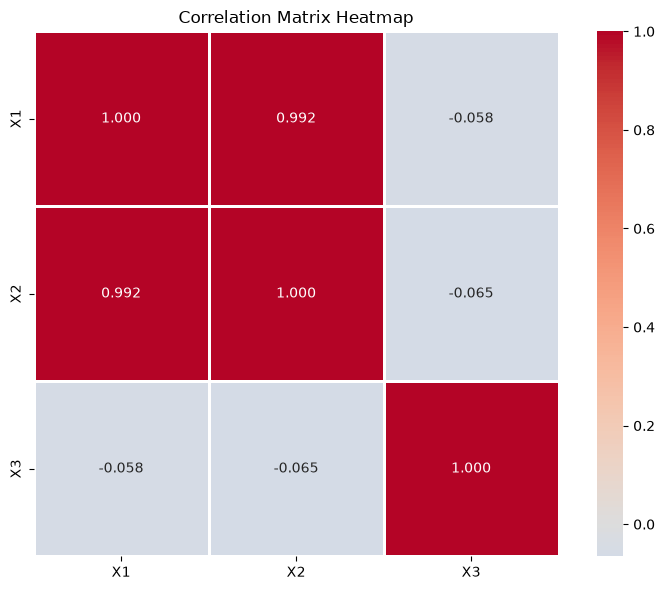


⚠️  HIGH MULTICOLLINEARITY DETECTED:
   X1 and X2: correlation = 0.992

[STEP 3] Calculating Variance Inflation Factor (VIF)...
--------------------------------------------------------------------------------

Variance Inflation Factors:
  Feature        VIF
0      X1  64.834719
1      X2  64.900793
2      X3   1.008338

VIF Interpretation:
   X1: VIF = 64.83 - ❌ High multicollinearity
   X2: VIF = 64.90 - ❌ High multicollinearity
   X3: VIF = 1.01 - ✓ Acceptable

[STEP 4] Calculating Condition Number...
--------------------------------------------------------------------------------
Condition Number: 16.41+0.00j
⚠️  Moderate multicollinearity

[STEP 5] Comparing different modeling approaches...
--------------------------------------------------------------------------------

5a. Ordinary Least Squares (OLS):
   Coefficients: [0.79375539 4.26754259 1.61716109]
   MSE: 0.8595
   R²: 0.9658

5b. Ridge Regression:
   Coefficients: [1.69943214 3.24801756 1.59598666]
   MSE: 0.8378
   R²: 

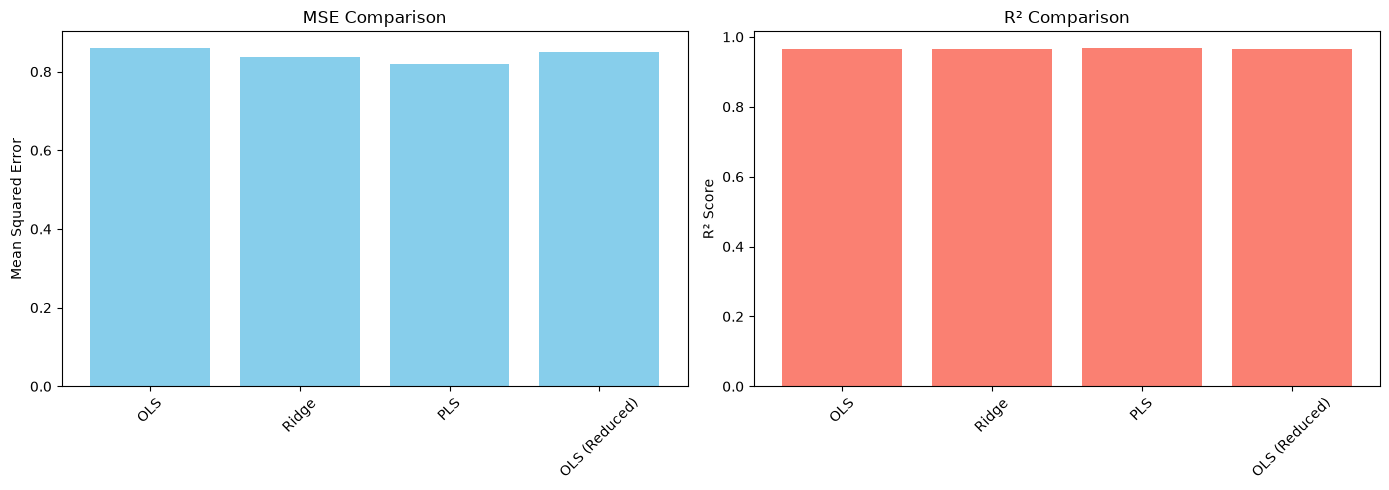


[STEP 7] Analyzing coefficient stability...
--------------------------------------------------------------------------------

Coefficient Standard Deviation (stability measure):
OLS coefficients std: [0.4296053  0.47269014 0.04194056]
Ridge coefficients std: [0.20336655 0.22404407 0.04254576]

Lower std = More stable coefficients


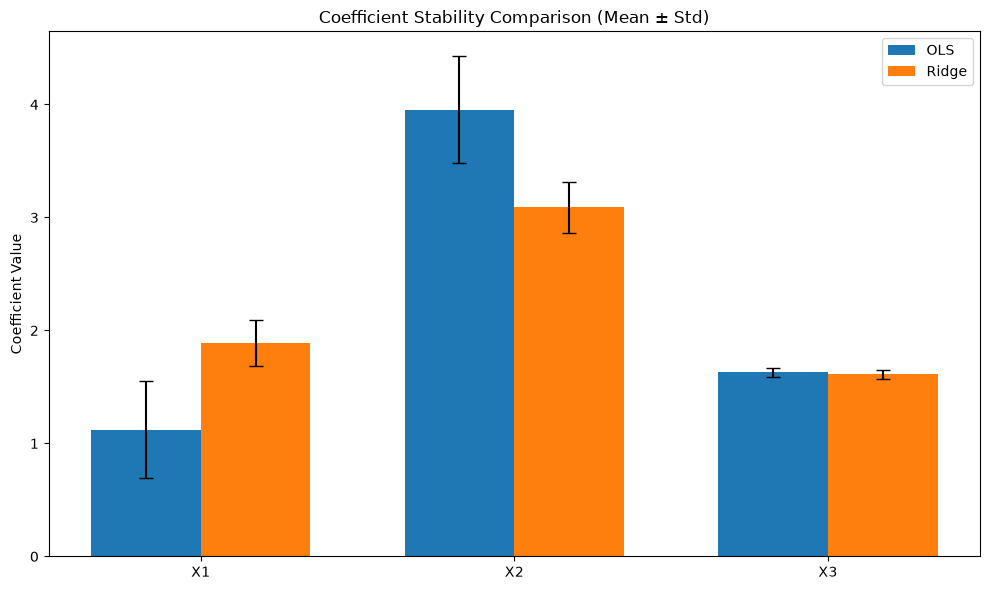


ANALYSIS COMPLETE

Key Takeaways:
1. Multicollinearity inflates coefficient variance (high VIF)
2. Ridge regression stabilizes coefficients through regularization
3. PLS handles multicollinearity by creating latent variables
4. Removing correlated variables is simple but may lose information
5. Choose method based on your goal: inference vs prediction


In [13]:
"""
Complete Multicollinearity Analysis Pipeline

This script demonstrates a complete workflow for:
1. Detecting multicollinearity
2. Assessing its severity
3. Applying appropriate solutions
4. Comparing model performance
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("="*80)
print("MULTICOLLINEARITY ANALYSIS PIPELINE")
print("="*80)

# Step 1: Generate synthetic dataset with multicollinearity
print("\n[STEP 1] Generating synthetic dataset with multicollinearity...")
print("-" * 80)

# Create base features
n_samples = 200
X_base = np.random.randn(n_samples, 3)

# Introduce multicollinearity: X2 is highly correlated with X1
X_multicollinear = np.column_stack([
    X_base[:, 0],                           # X1
    X_base[:, 0] * 0.9 + X_base[:, 1] * 0.1,  # X2 (highly correlated with X1)
    X_base[:, 2]                            # X3 (independent)
])

# Create target variable
y = 2 * X_multicollinear[:, 0] + 3 * X_multicollinear[:, 1] + \
    1.5 * X_multicollinear[:, 2] + np.random.normal(0, 1, n_samples)

# Create DataFrame for easier analysis
df = pd.DataFrame(X_multicollinear, columns=['X1', 'X2', 'X3'])
df['y'] = y

print(f"Dataset shape: {df.shape}")
print(f"Features: X1, X2 (correlated), X3")
print(f"Target: y")

# Step 2: Detect multicollinearity using correlation matrix
print("\n[STEP 2] Detecting multicollinearity using correlation matrix...")
print("-" * 80)

corr_matrix = df[['X1', 'X2', 'X3']].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Check for high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], 
                            corr_matrix.columns[j], 
                            corr_matrix.iloc[i, j]))

if high_corr:
    print(f"\n⚠️  HIGH MULTICOLLINEARITY DETECTED:")
    for var1, var2, corr in high_corr:
        print(f"   {var1} and {var2}: correlation = {corr:.3f}")
else:
    print("\n✓ No severe multicollinearity detected (correlation < 0.8)")

# Step 3: Calculate VIF
print("\n[STEP 3] Calculating Variance Inflation Factor (VIF)...")
print("-" * 80)

def calculate_vif_dataframe(dataframe, features):
    """Calculate VIF for each feature"""
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(dataframe[features].values, i) 
                       for i in range(len(features))]
    return vif_data

features = ['X1', 'X2', 'X3']
vif_results = calculate_vif_dataframe(df, features)

print("\nVariance Inflation Factors:")
print(vif_results)

# Interpret VIF
print("\nVIF Interpretation:")
for _, row in vif_results.iterrows():
    feature = row['Feature']
    vif = row['VIF']
    if vif < 5:
        status = "✓ Acceptable"
    elif vif < 10:
        status = "⚠️  Moderate multicollinearity"
    else:
        status = "❌ High multicollinearity"
    print(f"   {feature}: VIF = {vif:.2f} - {status}")

# Step 4: Calculate Condition Number
print("\n[STEP 4] Calculating Condition Number...")
print("-" * 80)

X = df[features].values
X_with_const = np.column_stack([np.ones(X.shape[0]), X])
eigenvalues = np.linalg.eigvals(np.dot(X_with_const.T, X_with_const))
condition_number = np.sqrt(np.max(eigenvalues) / np.min(eigenvalues))

print(f"Condition Number: {condition_number:.2f}")

if condition_number < 10:
    print("✓ Low multicollinearity")
elif condition_number < 30:
    print("⚠️  Moderate multicollinearity")
else:
    print("❌ High multicollinearity")

# Step 5: Compare different approaches
print("\n[STEP 5] Comparing different modeling approaches...")
print("-" * 80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5a: Ordinary Least Squares (OLS)
print("\n5a. Ordinary Least Squares (OLS):")
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
ols_pred = ols_model.predict(X_test)
ols_mse = mean_squared_error(y_test, ols_pred)
ols_r2 = r2_score(y_test, ols_pred)

print(f"   Coefficients: {ols_model.coef_}")
print(f"   MSE: {ols_mse:.4f}")
print(f"   R²: {ols_r2:.4f}")

# 5b: Ridge Regression
print("\n5b. Ridge Regression:")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"   Coefficients: {ridge_model.coef_}")
print(f"   MSE: {ridge_mse:.4f}")
print(f"   R²: {ridge_r2:.4f}")

# 5c: PLS Regression
print("\n5c. Partial Least Squares (PLS) Regression:")
pls_model = PLSRegression(n_components=2)
pls_model.fit(X_train, y_train)
pls_pred = pls_model.predict(X_test).flatten()
pls_mse = mean_squared_error(y_test, pls_pred)
pls_r2 = r2_score(y_test, pls_pred)

print(f"   Coefficients: {pls_model.coef_.flatten()}")
print(f"   MSE: {pls_mse:.4f}")
print(f"   R²: {pls_r2:.4f}")

# 5d: Remove correlated variable
print("\n5d. OLS after removing X2 (correlated variable):")
X_train_reduced = X_train[:, [0, 2]]  # Keep only X1 and X3
X_test_reduced = X_test[:, [0, 2]]

ols_reduced_model = LinearRegression()
ols_reduced_model.fit(X_train_reduced, y_train)
ols_reduced_pred = ols_reduced_model.predict(X_test_reduced)
ols_reduced_mse = mean_squared_error(y_test, ols_reduced_pred)
ols_reduced_r2 = r2_score(y_test, ols_reduced_pred)

print(f"   Coefficients: {ols_reduced_model.coef_}")
print(f"   MSE: {ols_reduced_mse:.4f}")
print(f"   R²: {ols_reduced_r2:.4f}")

# Step 6: Visualize comparison
print("\n[STEP 6] Visualizing model comparison...")
print("-" * 80)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'PLS', 'OLS (Reduced)'],
    'MSE': [ols_mse, ridge_mse, pls_mse, ols_reduced_mse],
    'R2': [ols_r2, ridge_r2, pls_r2, ols_reduced_r2]
})

print("\nModel Comparison Summary:")
print(comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE comparison
axes[0].bar(comparison['Model'], comparison['MSE'], color='skyblue')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('MSE Comparison')
axes[0].tick_params(axis='x', rotation=45)

# R² comparison
axes[1].bar(comparison['Model'], comparison['R2'], color='salmon')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Comparison')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Step 7: Coefficient stability analysis
print("\n[STEP 7] Analyzing coefficient stability...")
print("-" * 80)

# Calculate coefficients with different random seeds
coefficients_ols = []
coefficients_ridge = []

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # OLS
    ols = LinearRegression()
    ols.fit(X_tr, y_tr)
    coefficients_ols.append(ols.coef_)
    
    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr, y_tr)
    coefficients_ridge.append(ridge.coef_)

coefficients_ols = np.array(coefficients_ols)
coefficients_ridge = np.array(coefficients_ridge)

print("\nCoefficient Standard Deviation (stability measure):")
print(f"OLS coefficients std: {np.std(coefficients_ols, axis=0)}")
print(f"Ridge coefficients std: {np.std(coefficients_ridge, axis=0)}")
print("\nLower std = More stable coefficients")

# Visualize coefficient stability
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(features))
width = 0.35

ax.bar(x - width/2, np.mean(coefficients_ols, axis=0), width, 
       yerr=np.std(coefficients_ols, axis=0), label='OLS', capsize=5)
ax.bar(x + width/2, np.mean(coefficients_ridge, axis=0), width,
       yerr=np.std(coefficients_ridge, axis=0), label='Ridge', capsize=5)

ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Stability Comparison (Mean ± Std)')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nKey Takeaways:")
print("1. Multicollinearity inflates coefficient variance (high VIF)")
print("2. Ridge regression stabilizes coefficients through regularization")
print("3. PLS handles multicollinearity by creating latent variables")
print("4. Removing correlated variables is simple but may lose information")
print("5. Choose method based on your goal: inference vs prediction")


---

## Summary Flowchart

```mermaid
flowchart TB
    Start[Start: Build Regression Model] --> Detect{Detect Multicollinearity}
    
    Detect -->|Correlation Matrix| Corr["Check |r| > 0.8"]
    Detect -->|VIF| VIF["Check VIF > 5 or 10"]
    Detect -->|Condition Number| Cond["Check Cond > 30"]
    
    Corr --> Problem{Problem?}
    VIF --> Problem
    Cond --> Problem
    
    Problem -->|Yes| Choose[Choose Solution]
    Problem -->|No| Proceed[Proceed with Model]
    
    Choose --> Remove[Remove Variables]
    Choose --> Combine[Combine Variables]
    Choose --> Ridge[Use Ridge Regression]
    Choose --> PLS[Use PLS Regression]
    Choose --> Collect[Collect More Data]
    
    Remove --> Validate[Validate Model]
    Combine --> Validate
    Ridge --> Validate
    PLS --> Validate
    Collect --> Validate
    
    Validate --> Assess{Performance OK?}
    Assess -->|Yes| Final[Finalize Model]
    Assess -->|No| Choose
    
    Proceed --> Final
    Final --> End[End]
```

---

## Key Takeaways

1. **Detection is crucial**: Always check for multicollinearity before interpreting regression coefficients
2. **Context matters**: Multicollinearity is more problematic for inference than prediction
3. **Multiple solutions exist**: Choose based on your specific needs and data characteristics
4. **VIF is comprehensive**: Use VIF along with correlation matrix for thorough detection
5. **Regularization helps**: Ridge regression is often the most practical solution
6. **Trade-offs exist**: Each solution has advantages and disadvantages

---
